<a href="https://colab.research.google.com/github/Hyon2-park/test/blob/main/%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1_%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df=pd.read_csv('/content/구매내역정보.csv',encoding='cp949')
df.head()
customer=df.groupby("ID").agg(
    총구매금액=("구매금액","sum"),
    총구매횟수=("거래식별ID","nunique"),
    평균객단가=("구매금액","mean"),
    상품다양성=("상품대분류명","nunique"),
    점포다양성=("점포ID","nunique")
)
customer

,총구매금액,총구매횟수,평균객단가,상품다양성,점포다양성
ID,,,,,
B000001,225310,19,5239.767442,11,1
B000002,54900,3,6100.000000,5,1
B000003,109448,17,4560.333333,5,1
B000004,57050,4,4754.166667,6,1
B000005,155984,24,2999.692308,12,1
...,...,...,...,...,...
B001496,232350,13,5667.073171,9,1
B001497,245532,49,2888.611765,12,1
B001498,5720,2,1906.666667,2,1


In [49]:
df.groupby("ID")['거래일자'].nunique().sort_values(ascending=False)

,거래일자
ID,
B001088,58
B000142,57
B000301,56
B000906,54
B000090,53
...,...
B001455,1
B000030,1
B001467,1


In [10]:
customer['우수고객']=(customer['총구매금액'].quantile(0.8) <= customer['총구매금액']).astype(int)
customer

,총구매금액,총구매횟수,평균객단가,상품다양성,점포다양성,우수고객
ID,,,,,,
B000001,225310,19,5239.767442,11,1,0
B000002,54900,3,6100.000000,5,1,0
B000003,109448,17,4560.333333,5,1,0
B000004,57050,4,4754.166667,6,1,0
B000005,155984,24,2999.692308,12,1,0
...,...,...,...,...,...,...
B001496,232350,13,5667.073171,9,1,0
B001497,245532,49,2888.611765,12,1,0
B001498,5720,2,1906.666667,2,1,0


In [31]:
customer[(customer['점포다양성']>1).astype(int)]

,점포다양성
ID,
B000001,0
B000002,0
B000003,0
B000004,0
B000005,0
...,...
B001496,0
B001497,0
B001498,0


로지스틱 회귀
1. 데이터프레임 생성
2. 목표변수 생성

In [11]:
# 입력 변수(X), 목표변수(Y) 분리
#x=[입력변수]
customer.columns

Index(['총구매금액', '총구매횟수', '평균객단가', '상품다양성', '점포다양성', '우수고객'], dtype='object')

In [24]:
X=customer[['총구매횟수', '평균객단가', '상품다양성', '점포다양성']]

In [25]:
y=customer['우수고객']

In [26]:
# 학습용 데이터 분리
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [27]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000) # 1000번 학습
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
pred=model.predict(X_test)

정밀도 : 불량으로 예측한 거 중에 실제 불량 ( 세로 )



재현율 : 실제 불량 중 제대로 불량이라 예측한 비율 (가로)

In [28]:
#예측 평가 - 오차행렬
from sklearn.metrics import confusion_matrix, classification_report
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       351
           1       0.82      0.83      0.82        88

    accuracy                           0.93       439
   macro avg       0.89      0.89      0.89       439
weighted avg       0.93      0.93      0.93       439



f1-score >= 0.7 good

In [29]:
customer

,총구매금액,총구매횟수,평균객단가,상품다양성,점포다양성,우수고객
ID,,,,,,
B000001,225310,19,5239.767442,11,1,0
B000002,54900,3,6100.000000,5,1,0
B000003,109448,17,4560.333333,5,1,0
B000004,57050,4,4754.166667,6,1,0
B000005,155984,24,2999.692308,12,1,0
...,...,...,...,...,...,...
B001496,232350,13,5667.073171,9,1,0
B001497,245532,49,2888.611765,12,1,0
B001498,5720,2,1906.666667,2,1,0


In [32]:
고객 충성도
  <자주 방문는 고객인지 아닌지
  규칙적으로 방문하는지 (평균 30%)
  상품 다양성이 높은 고객인지 아닌지>

  vip 하락 고객 : 목적성 상품 구매 후 이용 중단 -> 연관 상품 추천
----------------------------------------------
시기별 잘 팔리는 상품 +

재구매빈도가 높은 상품 -> 이 사람들이 매출을 얼마나 차지 하는지
연관분석

휴면화 방

SyntaxError: invalid syntax (ipython-input-1761436968.py, line 1)

In [37]:
customer['총구매횟수'].quantile([0.25, 0.5, 0.75, 1.0])

,총구매횟수
0.25,4.0
0.50,10.0
0.75,19.0
1.00,86.0


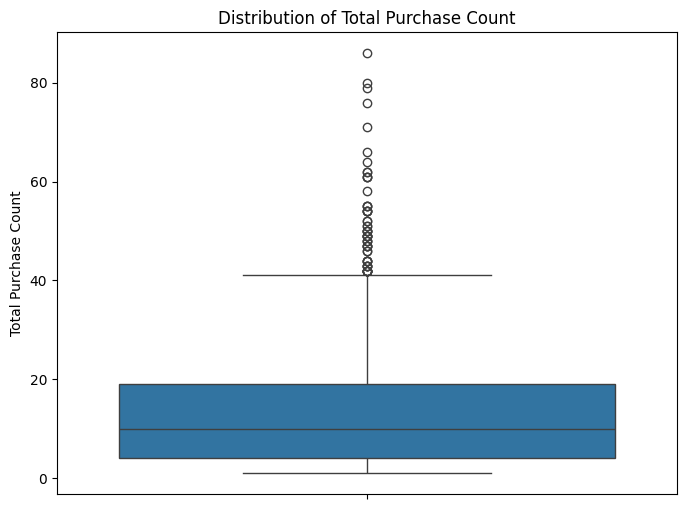

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=customer['총구매횟수'])
plt.title('Distribution of Total Purchase Count')
plt.ylabel('Total Purchase Count')
plt.show()

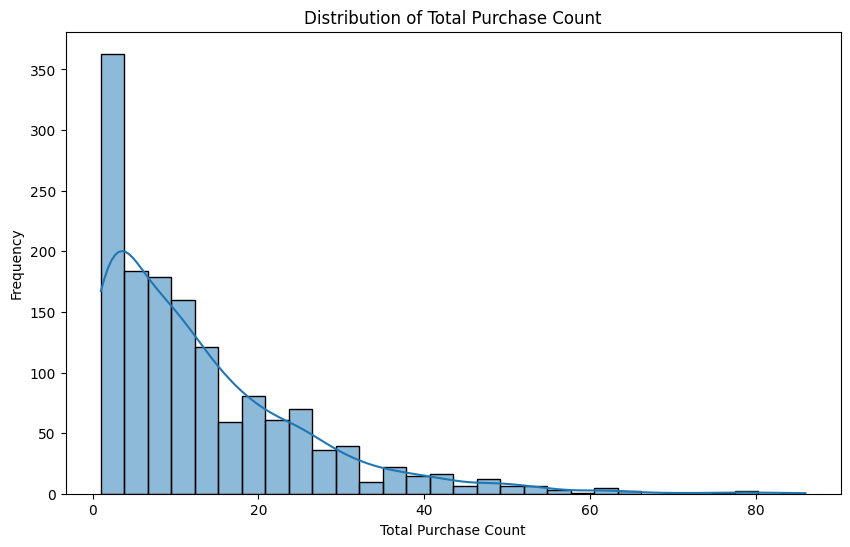

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(customer['총구매횟수'], bins=30, kde=True)
plt.title('Distribution of Total Purchase Count')
plt.xlabel('Total Purchase Count')
plt.ylabel('Frequency')
plt.show()

In [41]:
customer['총구매횟수'].mean()

np.float64(13.062927496580027)

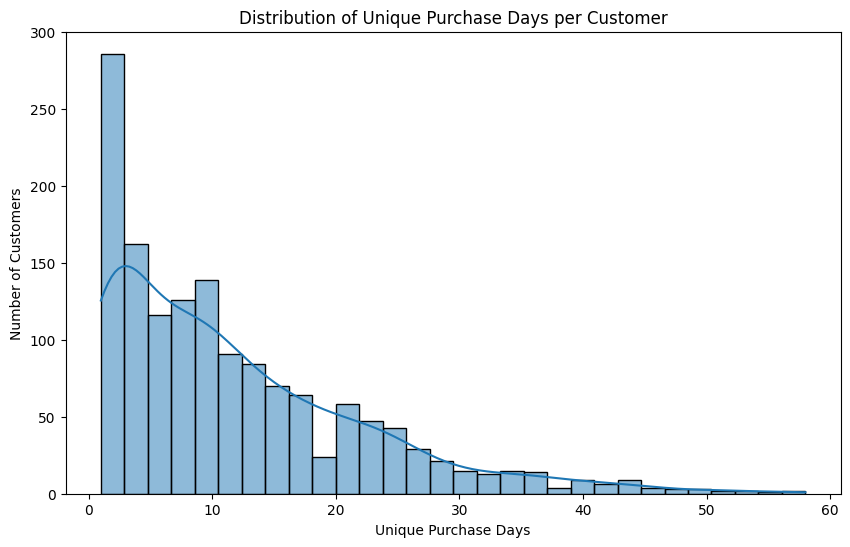

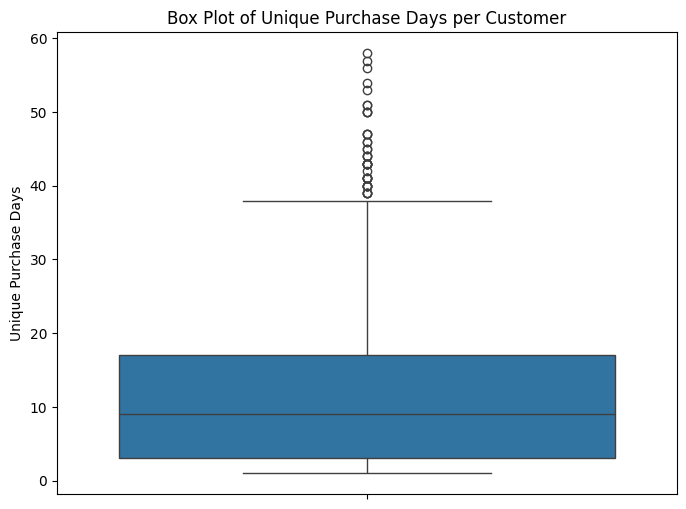

In [47]:
customer_purchase_days = df.groupby("ID")['거래일자'].nunique()

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(customer_purchase_days, bins=30, kde=True)
plt.title('Distribution of Unique Purchase Days per Customer')
plt.xlabel('Unique Purchase Days')
plt.ylabel('Number of Customers')
plt.show()

# Box plot
plt.figure(figsize=(8, 6))
sns.boxplot(y=customer_purchase_days)
plt.title('Box Plot of Unique Purchase Days per Customer')
plt.ylabel('Unique Purchase Days')
plt.show()